<a href="https://colab.research.google.com/github/Keistkmiya/Tugas1-MachineLearning/blob/main/Tugas1_Chapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Model Evaluation and Improvement

##Setup and Library Imports

In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import warnings

%matplotlib inline

## Cross-Validation

Cross-validation adalah metode statistik untuk mengevaluasi kinerja generalisasi yang lebih stabil dibandingkan pembagian tunggal menjadi *training* dan *test set*. Dalam *k-fold cross-validation*, data dibagi menjadi *k* bagian yang sama besar (disebut *fold*). Model dilatih sebanyak *k* kali, di mana setiap kali satu *fold* menjadi data uji dan sisanya menjadi data latih.

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

scores = cross_val_score(logreg, iris.data, iris.target, cv=5)

print("Skor Cross-validation per fold:\n", scores)
print("\nRata-rata skor Cross-validation: {:.3f}".format(scores.mean()))

Skor Cross-validation per fold:
 [0.96666667 1.         0.93333333 0.96666667 1.        ]

Rata-rata skor Cross-validation: 0.973


### Stratified k-Fold Cross-Validation

Pada dataset klasifikasi, pembagian k-fold biasa bisa berisiko jika data terurut berdasarkan labelnya. Stratified k-fold membagi data sedemikian rupa sehingga rasio tiap kelas di setiap fold tetap terjaga sesuai dengan proporsi pada dataset asli.

In [5]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5)
scores = cross_val_score(logreg, iris.data, iris.target, cv=kfold)

print("Skor Cross-validation (KFold biasa):\n", scores)

kfold_shuffled = KFold(n_splits=3, shuffle=True, random_state=0)
scores_shuffled = cross_val_score(logreg, iris.data, iris.target, cv=kfold_shuffled)

print("\nSkor Cross-validation (KFold dengan shuffle):\n", scores_shuffled)

Skor Cross-validation (KFold biasa):
 [1.         1.         0.86666667 0.93333333 0.83333333]

Skor Cross-validation (KFold dengan shuffle):
 [0.98 0.96 0.96]


### Leave-One-Out Cross-Validation (LOOCV)

Leave-one-out adalah bentuk ekstrim dari k-fold di mana setiap fold hanya berisi satu sampel tunggal. Jika saya memiliki 150 data, maka model akan dilatih sebanyak 150 kali. Metode ini sangat baik untuk dataset kecil, namun akan sangat lambat untuk dataset yang besar.

In [6]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)

print("Jumlah iterasi:", len(scores))
print("Rata-rata akurasi: {:.2f}".format(scores.mean()))

Jumlah iterasi: 150
Rata-rata akurasi: 0.97


### Shuffle-Split Cross-Validation

Shuffle-split membagi data secara acak dengan mengambil sejumlah sampel untuk data uji dan sisanya untuk data latih pada setiap iterasi. Saya bisa menentukan berapa kali pengulangan dilakukan (n_splits) dan berapa persentase data yang dijadikan data uji (test_size). Ini sangat berguna untuk mengontrol beban komputasi pada dataset besar.

In [7]:
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)

print("Skor Cross-validation:\n", scores)

Skor Cross-validation:
 [0.94666667 0.97333333 0.97333333 0.97333333 0.96       0.96
 0.94666667 0.92       1.         0.90666667]


## Grid Search

Setelah mengetahui cara mengevaluasi model, langkah selanjutnya adalah menemukan parameter terbaik (hyperparameters). Grid Search adalah metode untuk mencoba semua kombinasi parameter yang saya tentukan dan menemukan mana yang memberikan hasil evaluasi terbaik.

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svc = SVC(gamma=gamma, C=C)
        svc.fit(X_train, y_train)
        score = svc.score(X_test, y_test)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print("Skor terbaik: {:.2f}".format(best_score))
print("Parameter terbaik:", best_parameters)

Skor terbaik: 0.97
Parameter terbaik: {'C': 100, 'gamma': 0.001}


### The Danger of Overfitting the Parameters and the Validation Set

Menggunakan data uji yang sama untuk mengevaluasi hasil dan memilih parameter dapat menyebabkan model saya terlihat lebih baik daripada kenyataannya. Oleh karena itu, saya akan membagi data menjadi tiga bagian: data latih untuk membangun model, data validasi untuk memilih parameter terbaik, dan data uji untuk evaluasi akhir yang tidak bias.

In [9]:
from sklearn.svm import SVC

X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, random_state=0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1)

print("Size of training set: {}   size of validation set: {}   size of test set:"
      " {}\n".format(X_train.shape[0], X_valid.shape[0], X_test.shape[0]))

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svc = SVC(gamma=gamma, C=C)
        svc.fit(X_train, y_train)
        score = svc.score(X_valid, y_valid)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

svc = SVC(**best_parameters)
svc.fit(X_trainval, y_trainval)
test_score = svc.score(X_test, y_test)

print("Best score on validation set: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)
print("Test set score with best parameters: {:.2f}".format(test_score))

Size of training set: 84   size of validation set: 28   size of test set: 38

Best score on validation set: 0.96
Best parameters:  {'C': 10, 'gamma': 0.001}
Test set score with best parameters: 0.92


### Grid Search with Cross-Validation (GridSearchCV)

Menggunakan GridSearchCV jauh lebih efisien karena scikit-learn secara otomatis menangani pembagian data, pencarian parameter, dan evaluasi menggunakan cross-validation. Ini mengurangi risiko bias dan membuat kode saya jauh lebih bersih.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0)

grid_search.fit(X_train, y_train)

print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Test set score: 0.97
Best parameters: {'C': 10, 'gamma': 0.1}
Best cross-validation score: 0.97


### Analyzing the Result of Cross-Validation

Saya bisa melihat hasil lengkap dari setiap kombinasi parameter yang dicoba melalui atribut `cv_results_`. Untuk memudahkannya, saya akan mengubahnya menjadi DataFrame Pandas.

In [11]:
results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008429,0.002120,0.005360,0.000808,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.004797,0.000478,0.004003,0.000436,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.005140,0.001722,0.003857,0.001238,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.005576,0.001125,0.003564,0.000926,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.006508,0.001172,0.004223,0.000911,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


### Visualizing the Grid Search Results

Kita akan memvisualisasikan skor rata-rata cross-validation dalam bentuk heatmap. Sumbu-x mewakili parameter `gamma` dan sumbu-y mewakili parameter `C`. Visualisasi ini membantu saya memahami bagaimana perubahan parameter mempengaruhi performa model secara keseluruhan.

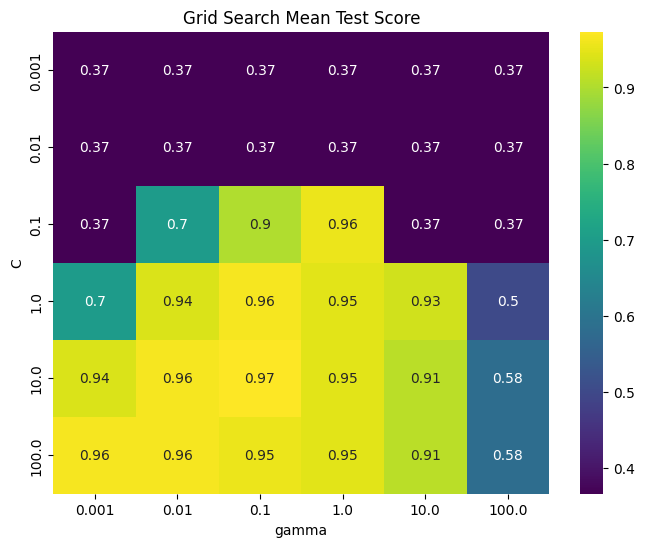

In [13]:
import seaborn as sns

scores = results.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(scores, annot=True, cmap='viridis')
plt.title("Grid Search Mean Test Score")
plt.xlabel("gamma")
plt.ylabel("C")
plt.show()

## Nested Cross-Validation

Nested cross-validation digunakan untuk mengevaluasi model seakurat mungkin tanpa bias dari pemilihan parameter. Di sini, saya memiliki loop luar untuk membagi data menjadi train/test, dan loop dalam (GridSearchCV) untuk mencari parameter terbaik di setiap fold-nya.

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5),
                         iris.data, iris.target, cv=5)

print("Skor Cross-validation: ", scores)
print("Rata-rata skor: ", scores.mean())

Skor Cross-validation:  [0.96666667 1.         0.96666667 0.96666667 1.        ]
Rata-rata skor:  0.9800000000000001


## Evaluation Metrics and Scoring

Meskipun akurasi adalah metrik yang umum digunakan, metrik ini bisa sangat menyesatkan untuk dataset yang tidak seimbang (imbalanced dataset). Misalnya, jika 90% data adalah kelas A dan 10% kelas B, model "bodoh" yang selalu menebak kelas A akan mendapat akurasi 90%. Oleh karena itu, saya perlu menggunakan matriks kebingungan (Confusion Matrix) untuk melihat secara detail prediksi mana yang benar dan mana yang salah (True Positive, False Positive, True Negative, False Negative).

In [15]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

digits = load_digits()
y = digits.target == 9

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

logreg = LogisticRegression(C=0.1, max_iter=1000).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)

confusion = confusion_matrix(y_test, pred_logreg)
print("Confusion matrix:\n{}".format(confusion))

Confusion matrix:
[[402   1]
 [  6  41]]


### Precision, Recall, and f1-score

Dari Confusion Matrix, saya bisa menghitung metrik yang jauh lebih informatif daripada sekadar akurasi:
* **Precision**: Seberapa banyak prediksi positif dari model saya yang benar-benar positif.
* **Recall**: Seberapa banyak kasus positif aktual yang berhasil dideteksi oleh model saya.
* **f1-score**: Rata-rata harmonis dari Precision dan Recall.

Untuk melihat semua metrik ini sekaligus, saya dapat menggunakan fungsi `classification_report`.

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_logreg,
                            target_names=["not nine", "nine"]))

              precision    recall  f1-score   support

    not nine       0.99      1.00      0.99       403
        nine       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450

